11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0663 - val_loss: 0.0423
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0369 - val_loss: 0.0331
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0305 - val_loss: 0.0287
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0275 - val_loss: 0.0266
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0257 - val_loss: 0.0251
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


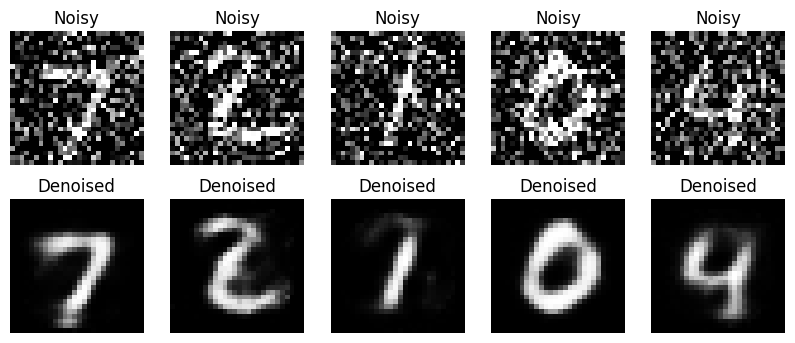

In [1]:
# ================= STEP 1: IMPORT =================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# ================= STEP 2: LOAD DATA =================
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# ================= STEP 3: NORMALIZE =================
x_train = x_train / 255.0
x_test = x_test / 255.0

# ================= STEP 4: ADD NOISE =================
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ================= STEP 5: BUILD AUTOENCODER =================
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28))
])

# ================= STEP 6: COMPILE =================
model.compile(
    optimizer='adam',
    loss='mse'
)

# ================= STEP 7: TRAIN =================
model.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

# ================= STEP 8: PREDICT =================
decoded = model.predict(x_test_noisy)

# ================= STEP 9: VISUALIZE =================
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Noisy
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(decoded[i], cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()